# Language ranking by naive speakers per country

This notebook ranks languages from highest to lowest by:

`naive_speakers_per_country = Number of speakers / country_count`

Rules used here:
1. `country_count` comes from splitting `Countries` on commas and trimming whitespace.
2. Rows with empty `Countries` are excluded.
3. `Number of speakers` is parsed as numeric after removing commas.

In [1]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path('data.csv')
OUTPUT_PATH = Path('outputs/language_rankings_by_naive_speakers_per_country.csv')

df = pd.read_csv(DATA_PATH)
df.head(3)

,ID,Name in English,Name in French,Name in Spanish,Countries,Country codes alpha 3,ISO639-3 codes,Degree of endangerment,Alternate names,Name in the language,Number of speakers,Sources,Latitude,Longitude,Description of the location
0,1022,South Italian,italien du sud,napolitano-calabrés,Italy,ITA,nap,Vulnerable,Neapolitan; Neapolitan-Calabrese; неаполитанск...,NaN,7500000.0,NaN,40.9798,15.2490,"Campania, Lucania (Basilicata), Abruzzi (Abruz..."
1,1023,Sicilian,sicilien,siciliano,Italy,ITA,scn,Vulnerable,NaN,NaN,5000000.0,NaN,37.4399,14.5019,"Sicily (Sicilia), southern and central Calabri..."
2,383,Low Saxon,bas-saxon,bajo sajón,"Germany, Denmark, Netherlands, Poland, Russian...","DEU, DNK, NLD, POL, RUS","act, drt, frs, gos, nds, sdz, stl, twd, vel, wep",Vulnerable,"Low German, Niedersächsisch, Nedersaksisch, Ni...",Neddersassisch,4800000.0,NaN,53.4029,10.3601,"northern Germany, the north-eastern part of th..."


In [2]:
countries_series = df['Countries'].fillna('').astype(str).str.strip()
speakers_series = pd.to_numeric(
    df['Number of speakers'].fillna('').astype(str).str.replace(',', '', regex=False),
    errors='coerce',
)

filtered = df.loc[countries_series != ''].copy()
filtered['Number of speakers numeric'] = speakers_series.loc[filtered.index]
filtered = filtered.dropna(subset=['Number of speakers numeric']).copy()

filtered['country_count'] = (
    filtered['Countries']
    .astype(str)
    .str.split(',')
    .apply(lambda parts: sum(1 for country in parts if country.strip()))
)

filtered['naive_speakers_per_country'] = (
    filtered['Number of speakers numeric'] / filtered['country_count']
)

ranking = filtered[
    [
        'ID',
        'Name in English',
        'Degree of endangerment',
        'Countries',
        'Number of speakers',
        'country_count',
        'naive_speakers_per_country',
    ]
].sort_values('naive_speakers_per_country', ascending=False)

ranking.head(25)

,ID,Name in English,Degree of endangerment,Countries,Number of speakers,country_count,naive_speakers_per_country
0,1022,South Italian,Vulnerable,Italy,7500000.0,1,7500000.0
1,1023,Sicilian,Vulnerable,Italy,5000000.0,1,5000000.0
6,2211,Yiddish (Israel),Definitely endangered,Israel,3000000.0,1,3000000.0
7,1586,Gondi,Vulnerable,India,2713790.0,1,2713790.0
9,1943,Quechua of Southern Bolivia,Vulnerable,Bolivia (Plurinational State of),2300000.0,1,2300000.0
15,1985,Zazaki,Vulnerable,Turkey,2000000.0,1,2000000.0
13,399,Piedmontese,Definitely endangered,Italy,2000000.0,1,2000000.0
16,1591,Kurux (India),Vulnerable,India,1751489.0,1,1751489.0
4,382,Lombard,Definitely endangered,"Italy, Switzerland",3500000.0,2,1750000.0
17,2065,Tamajeq,Vulnerable,Niger,1750000.0,1,1750000.0


In [3]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
ranking.to_csv(OUTPUT_PATH, index=False)

print(f'Rows ranked: {len(ranking)}')
print(f'Output written to: {OUTPUT_PATH.resolve()}')

Rows ranked: 2538
Output written to: /Users/tsteele/Documents/GitHub/2026-fall/data-scrubbing-fun/outputs/language_rankings_by_naive_speakers_per_country.csv


## Summary table

Condensed view: language name, endangerment status, number of countries, and naive speakers per country — sorted highest to lowest.

In [4]:
summary = (
    ranking[['Name in English', 'Degree of endangerment', 'country_count', 'naive_speakers_per_country']]
    .rename(columns={
        'Name in English': 'Language',
        'Degree of endangerment': 'Endangerment',
        'country_count': '# Countries',
        'naive_speakers_per_country': 'Speakers / Country',
    })
    .reset_index(drop=True)
)

summary['Speakers / Country'] = summary['Speakers / Country'].round(0).astype(int)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(summary)

,Language,Endangerment,# Countries,Speakers / Country
0,South Italian,Vulnerable,1,7500000
1,Sicilian,Vulnerable,1,5000000
2,Yiddish (Israel),Definitely endangered,1,3000000
3,Gondi,Vulnerable,1,2713790
4,Quechua of Southern Bolivia,Vulnerable,1,2300000
5,Zazaki,Vulnerable,1,2000000
6,Piedmontese,Definitely endangered,1,2000000
7,Kurux (India),Vulnerable,1,1751489
8,Lombard,Definitely endangered,2,1750000
9,Tamajeq,Vulnerable,1,1750000


## Speakers vs. endangerment

Each point is one language. Speaker count is log-scaled to handle the wide range (0 to 7.5M). Endangerment levels are ordered from least to most severe.

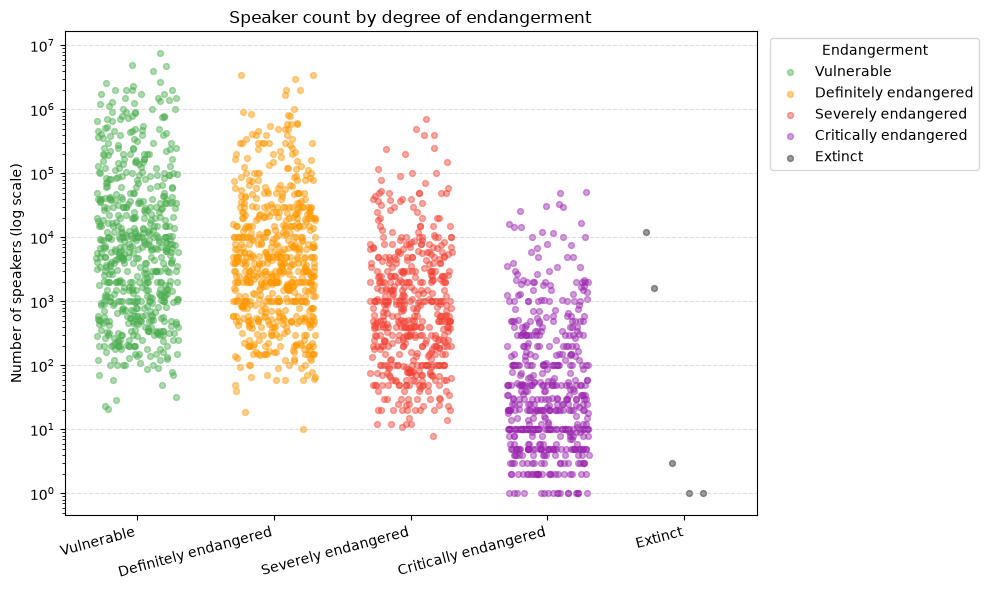

In [5]:
import matplotlib.pyplot as plt
import numpy as np

ORDER = [
    'Vulnerable',
    'Definitely endangered',
    'Severely endangered',
    'Critically endangered',
    'Extinct',
]
COLORS = {
    'Vulnerable':             '#4caf50',
    'Definitely endangered':  '#ff9800',
    'Severely endangered':    '#f44336',
    'Critically endangered':  '#9c27b0',
    'Extinct':                '#212121',
}

plot_df = filtered[filtered['Degree of endangerment'].isin(ORDER)].copy()
plot_df['level_idx'] = plot_df['Degree of endangerment'].map({v: i for i, v in enumerate(ORDER)})

# jitter x so points don't stack
rng = np.random.default_rng(42)
jitter = rng.uniform(-0.3, 0.3, size=len(plot_df))

fig, ax = plt.subplots(figsize=(10, 6))

for level in ORDER:
    mask = plot_df['Degree of endangerment'] == level
    x = plot_df.loc[mask, 'level_idx'] + jitter[mask.values]
    y = plot_df.loc[mask, 'Number of speakers numeric']
    ax.scatter(x, y, color=COLORS[level], alpha=0.45, s=18, label=level)

ax.set_yscale('log')
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels(ORDER, rotation=15, ha='right')
ax.set_ylabel('Number of speakers (log scale)')
ax.set_title('Speaker count by degree of endangerment')
ax.legend(title='Endangerment', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()